# XGBoost Hyperparameters 🎯

## Classification Hyperparameters

| Hyperparameter       | Importance 💡 | Description |
|----------------------|---------------|-------------|
| **n_estimators**     | ⭐⭐⭐⭐         | Number of trees (boosting rounds). Too high → overfitting; too low → underfitting. |
| **max_depth**        | ⭐⭐⭐⭐         | How deep each tree can go. Higher = more complex splits, risk of overfitting. |
| **learning_rate (eta)** | ⭐⭐⭐⭐     | Shrinks the contribution of each tree. Lower = more precise, but slower. |
| **subsample**        | ⭐⭐⭐          | % of rows used per tree. Helps reduce overfitting. Usually between 0.5 and 1. |
| **colsample_bytree** | ⭐⭐⭐          | % of features used per tree. Adds randomness and prevents overfit. |
| **gamma**            | ⭐⭐           | Minimum loss reduction required to make a split. Higher → more conservative splits. |
| **min_child_weight** | ⭐⭐           | Minimum sum of instance weights needed in a child. Higher = prevents overfitting. |
| **scale_pos_weight** | ⭐ (Imbalanced data) | Balances positive vs. negative classes for imbalanced datasets. |
| **reg_alpha**        | ⭐            | L1 regularization term. Encourages sparsity (zero coefficients). |
| **reg_lambda**       | ⭐            | L2 regularization term. Helps reduce model complexity. |

---




In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv("covid_toy.csv")

In [4]:
data

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No
...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No
96,51,Female,101.0,Strong,Kolkata,Yes
97,20,Female,101.0,Mild,Bangalore,No
98,5,Female,98.0,Strong,Mumbai,No


In [9]:
if data['has_covid'].dtype == 'object':
    data['has_covid'] = data['has_covid'].map({'No': 0, 'Yes': 1})

In [12]:
label_cols = ['gender', 'cough', 'city']

for col in label_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [14]:
X = data.drop('has_covid', axis=1)
y = data['has_covid']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
clf = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=4,
    eta=0.1,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

In [17]:
clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.1, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [18]:
y_pred = clf.predict(X_test)


In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.45
              precision    recall  f1-score   support

           0       0.50      0.55      0.52        11
           1       0.38      0.33      0.35         9

    accuracy                           0.45        20
   macro avg       0.44      0.44      0.44        20
weighted avg       0.44      0.45      0.45        20



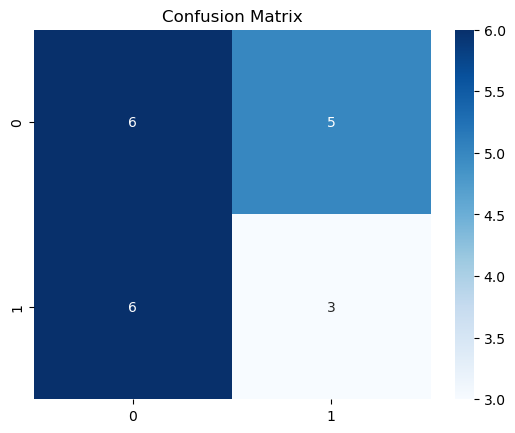

In [20]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [28]:
param_grid_c = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [100, 150],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1],
    'min_child_weight': [1, 3],
    'reg_alpha': [0, 0.5],       # L1 regularization
    'reg_lambda': [1, 2]         # L2 regularization
}

In [29]:
clf = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss')

grid_c = GridSearchCV(
    estimator=clf,
    param_grid=param_grid_c,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [30]:
grid_c.fit(X_train, y_train)

print("Best Parameters (Classification):", grid_c.best_params_)

best = grid_c.best_estimator_
y_pred = best.predict(X_test)
print("Accuracy (Tuned):", accuracy_score(y_test, y_pred))

Fitting 3 folds for each of 512 candidates, totalling 1536 fits
Best Parameters (Classification): {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}
Accuracy (Tuned): 0.4
